In [1]:
import pandas as pd

In [2]:
#loading and orienting the data
expr_raw = pd.read_csv('brca_metabric/data_mrna_illumina_microarray.txt', sep='\t', comment='#')

#drop rows with no gene symbol, collapse duplicate symbols by mean
expr_raw = expr_raw.dropna(subset=['Hugo_Symbol'])
expr_raw = expr_raw.drop(columns=['Entrez_Gene_Id'])
expr_raw = expr_raw.groupby('Hugo_Symbol').mean(numeric_only=True)
expr_raw.head()

,MB-0362,MB-0346,MB-0386,MB-0574,MB-0185,MB-0503,MB-0641,MB-0201,MB-0218,MB-0316,...,MB-6192,MB-4820,MB-5527,MB-5167,MB-5465,MB-5453,MB-5471,MB-5127,MB-4313,MB-4823
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,5.662294,5.854950,5.743328,5.716885,5.504649,5.948696,5.725525,5.734731,5.788228,5.763666,...,5.501222,5.649023,5.654469,5.642720,5.431803,5.732303,5.503984,5.550886,6.101505,5.633491
A1CF,5.350444,5.609458,5.435237,5.571744,5.257009,5.233115,5.311067,5.273068,5.207229,5.347844,...,5.613889,5.317775,5.652508,5.507495,5.202999,5.365232,5.285782,5.488379,5.356509,5.689814
A2M,7.653319,6.564312,8.201633,7.587296,8.427318,7.545219,8.693606,8.898809,8.763382,9.100264,...,7.736627,9.005442,8.696260,8.796967,10.127953,11.078945,8.714076,8.333257,10.018235,9.466299
A2ML1,5.535317,5.938013,5.337279,5.221707,5.514548,5.279701,5.201008,5.695971,5.108838,6.942946,...,5.265792,5.254453,7.689091,5.363285,5.865814,5.378435,5.600398,5.247741,5.421864,6.040639
A4GALT,6.347507,5.567505,6.923349,5.756924,6.154819,6.407954,7.228863,6.608221,5.947872,6.951467,...,7.053883,5.849546,6.460017,7.708127,7.016025,6.598701,6.837395,6.093857,7.225162,6.353837


In [3]:
#transpose: rows = patients, columns = genes
expr = expr_raw.transpose()
expr.index.name = 'PATIENT_ID'
expr = expr.reset_index()

print(expr.shape)
expr.head()

(1980, 20386)


Hugo_Symbol,PATIENT_ID,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AA06,AAA1,AAAS,...,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,hCG_1997999,hCG_2023280,psiTPTE22
0,MB-0362,5.662294,5.350444,7.653319,5.535317,6.347507,5.264170,5.259617,5.391005,6.479471,...,5.845263,6.434705,5.321824,8.674482,9.018941,7.558310,7.003461,6.008556,5.355926,5.269515
1,MB-0346,5.854950,5.609458,6.564312,5.938013,5.567505,5.285960,5.179630,5.377596,6.511604,...,6.191387,6.567050,5.388879,8.091321,8.292709,7.159059,7.354656,5.772867,5.350325,5.012334
2,MB-0386,5.743328,5.435237,8.201633,5.337279,6.923349,5.275596,5.467693,5.127266,6.183451,...,5.690757,6.381255,5.429683,8.759179,9.162176,7.484611,6.853452,5.621497,5.428751,5.401948
3,MB-0574,5.716885,5.571744,7.587296,5.221707,5.756924,5.209861,5.222671,5.259309,6.079376,...,6.612426,6.919791,5.093761,8.778374,8.169537,7.639262,7.240531,5.509456,5.263631,5.227373
4,MB-0185,5.504649,5.257009,8.427318,5.514548,6.154819,5.613277,5.497661,5.443880,6.401032,...,5.982131,6.363514,5.329793,8.481611,8.787354,7.447219,7.118362,5.567187,5.329880,5.250153


In [4]:
#QC: check for missing values
#.drop() vs .dropna() - drop() removes columns or rows by name, dropna() removes rows or columns with missing values
missing_per_gene = expr.drop(columns='PATIENT_ID').isnull().mean() #this is to find the proportion of missing values per gene 
genes_to_drop = missing_per_gene[missing_per_gene > 0.2].index #drop genes with more than 20% missing values
expr = expr.drop(columns=genes_to_drop) 
print(f"Dropped {len(genes_to_drop)} genes with >20% missing values. Remaining genes: {expr.shape[1]-1}") #shape[1]-1 because we don't want to count the PATIENT_ID column

Dropped 0 genes with >20% missing values. Remaining genes: 20385


In [5]:
#Fill any remaining missing values with the gene-wise median (safer than mean because it is less sensitive to outliers, for expression data)
gene_cols = expr.columns.drop('PATIENT_ID')
expr[gene_cols] = expr[gene_cols].fillna(expr[gene_cols].median())
expr.head()

Hugo_Symbol,PATIENT_ID,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AA06,AAA1,AAAS,...,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,hCG_1997999,hCG_2023280,psiTPTE22
0,MB-0362,5.662294,5.350444,7.653319,5.535317,6.347507,5.264170,5.259617,5.391005,6.479471,...,5.845263,6.434705,5.321824,8.674482,9.018941,7.558310,7.003461,6.008556,5.355926,5.269515
1,MB-0346,5.854950,5.609458,6.564312,5.938013,5.567505,5.285960,5.179630,5.377596,6.511604,...,6.191387,6.567050,5.388879,8.091321,8.292709,7.159059,7.354656,5.772867,5.350325,5.012334
2,MB-0386,5.743328,5.435237,8.201633,5.337279,6.923349,5.275596,5.467693,5.127266,6.183451,...,5.690757,6.381255,5.429683,8.759179,9.162176,7.484611,6.853452,5.621497,5.428751,5.401948
3,MB-0574,5.716885,5.571744,7.587296,5.221707,5.756924,5.209861,5.222671,5.259309,6.079376,...,6.612426,6.919791,5.093761,8.778374,8.169537,7.639262,7.240531,5.509456,5.263631,5.227373
4,MB-0185,5.504649,5.257009,8.427318,5.514548,6.154819,5.613277,5.497661,5.443880,6.401032,...,5.982131,6.363514,5.329793,8.481611,8.787354,7.447219,7.118362,5.567187,5.329880,5.250153


In [6]:
#Cell: load both datasets
clinical_final = pd.read_csv('brca_metabric/clinical_final.csv')

#Cell: diagnostic check
missing_subtype_ids = clinical_final.loc[clinical_final['CLAUDIN_SUBTYPE'].isnull(), 'PATIENT_ID']
overlap = expr['PATIENT_ID'].isin(missing_subtype_ids).sum()

if len(missing_subtype_ids) == 0:
    print("No patients are missing CLAUDIN_SUBTYPE.")
else:
    print(f"Of {len(missing_subtype_ids)} patients missing CLAUDIN_SUBTYPE, {overlap} have expression data anyway.")


#Cell: build merged DEG-analysis dataframe
merged = expr.merge(clinical_final[['PATIENT_ID','CLAUDIN_SUBTYPE']], on='PATIENT_ID')
merged = merged.dropna(subset=['CLAUDIN_SUBTYPE'])
merged = merged[merged['CLAUDIN_SUBTYPE'] != 'NC']
print(merged['CLAUDIN_SUBTYPE'].value_counts())

Of 529 patients missing CLAUDIN_SUBTYPE, 0 have expression data anyway.
CLAUDIN_SUBTYPE
LumA           700
LumB           475
Her2           224
claudin-low    218
Basal          209
Normal         148
Name: count, dtype: int64


In [7]:
#Cell: check for patient ID overlap between gene expression and clinical data
clinical = pd.read_csv('brca_metabric/clinical_final.csv')
expr_ids = set(expr['PATIENT_ID'])
clin_ids = set(clinical['PATIENT_ID'])

print("expr count:", len(expr_ids))
print("clinical count:", len(clin_ids))
print("intersection:", len(expr_ids & clin_ids))
print("in clinical not expr (sample):", list(clin_ids - expr_ids)[:10])
print("in expr not clinical (sample):", list(expr_ids - clin_ids)[:10])

expr count: 1980
clinical count: 2509
intersection: 1980
in clinical not expr (sample): ['MTS-T0366', 'MTS-T0225', 'MTS-T0089', 'MTS-T0251', 'MB-0329', 'MTS-T0164', 'MTS-T2413', 'MTS-T0689', 'MTS-T2414', 'MTS-T0064']
in expr not clinical (sample): []


In [8]:
gene_cols = expr.columns.drop('PATIENT_ID')
print(expr[gene_cols].dtypes.value_counts())
print("Duplicate gene columns:", expr.columns.duplicated().sum())

float64    20385
Name: count, dtype: int64
Duplicate gene columns: 0


In [9]:
#Cell: DEG analysis is performed using ANOVA F-test to find genes that are differentially expressed across the CLAUDIN_SUBTYPE groups. The top 500 genes with the smallest p-values are selected as DEGs.
from sklearn.feature_selection import f_classif
import pandas as pd

gene_cols = expr.columns.drop('PATIENT_ID')

#Ensure numeric dtype (fixes it if diagnostic above showed object dtype)
X_genes = merged[gene_cols].apply(pd.to_numeric, errors='coerce')
y_labels = merged['CLAUDIN_SUBTYPE'].values

f_scores, p_values = f_classif(X_genes.values, y_labels)

deg_pvals = pd.Series(p_values, index=gene_cols).sort_values()
top_genes = deg_pvals.head(500).index.tolist()

print(f"Selected {len(top_genes)} DEGs, smallest p-value: {deg_pvals.min():.2e}")
deg_pvals.to_csv('brca_metabric/deg_pvalues.csv')

Selected 500 DEGs, smallest p-value: 0.00e+00


In [10]:
print(deg_pvals.head(15))

Hugo_Symbol
ESR1         0.000000e+00
FOXC1        0.000000e+00
FOXA1        0.000000e+00
AGR3         0.000000e+00
PSAT1        0.000000e+00
MLPH         0.000000e+00
CA12         0.000000e+00
TBC1D9       0.000000e+00
GATA3        0.000000e+00
BCL11A      3.148087e-318
SPDEF       4.079149e-316
XBP1        8.451330e-304
FAM171A1    6.780699e-300
TFF3        2.400883e-285
HAPLN3      3.838800e-282
dtype: float64


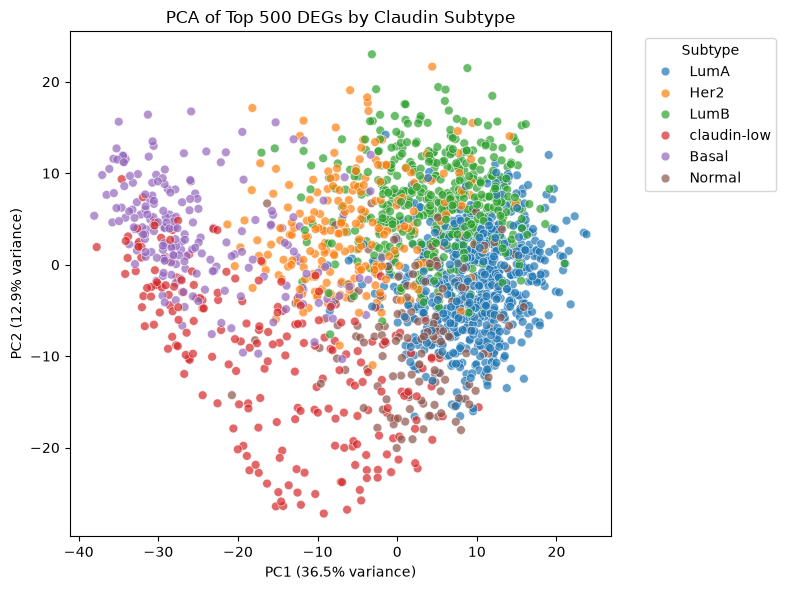

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

#Use the top 500 DEGs from the merged dataframe (has CLAUDIN_SUBTYPE attached)
X_deg = merged[top_genes]

#Standardize before PCA — required since genes are on different scales
X_scaled = StandardScaler().fit_transform(X_deg)

pca = PCA(n_components=2, random_state=42) 
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pcs[:, 0],
    y=pcs[:, 1],
    hue=merged['CLAUDIN_SUBTYPE'],
    palette='tab10',
    alpha=0.7,
    s=40,
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)") 
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of Top 500 DEGs by Claudin Subtype")
plt.legend(title="Subtype", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# run this in a notebook cell, not the terminal
import sys
!{sys.executable} -m pip install gseapy

In [26]:
import numpy as np
import pandas as pd

expr_for_gsea = merged.set_index('PATIENT_ID')[expr.columns.drop('PATIENT_ID')].T

# split patients into chunks so each ssgsea call handles less memory
batches = np.array_split(expr_for_gsea.columns, 6)  # 6 chunks of ~330 patients each
results = []

gene_sets_path = "D:/MODEL/h.all.v2026.1.Hs.symbols.gmt"

for i, batch_cols in enumerate(batches):
    print(f"Processing batch {i+1}/{len(batches)} ({len(batch_cols)} patients)...")
    res = gp.ssgsea(
        data=expr_for_gsea[batch_cols],
        gene_sets=gene_sets_path,
        outdir=None,
        sample_norm_method='rank',
        min_size=5
    )
    results.append(res.res2d)

combined = pd.concat(results)
pathway_scores = combined.pivot(index='Name', columns='Term', values='ES')
pathway_scores.index.name = 'PATIENT_ID'
pathway_scores = pathway_scores.reset_index()
pathway_scores.to_csv('brca_metabric/pathway_scores.csv', index=False)
print(pathway_scores.shape)  
pathway_scores.head()

Processing batch 1/6 (329 patients)...
Processing batch 2/6 (329 patients)...
Processing batch 3/6 (329 patients)...
Processing batch 4/6 (329 patients)...
Processing batch 5/6 (329 patients)...
Processing batch 6/6 (329 patients)...
(1974, 51)


Term,PATIENT_ID,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,HALLMARK_PROTEIN_SECRETION,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_XENOBIOTIC_METABOLISM
0,MB-0000,6872.856283,2969.274340,5370.827176,4965.985856,4003.663662,2698.369918,5563.291628,2737.862428,5405.645471,...,5639.844671,6061.587784,-937.786631,5362.894190,5807.028131,5857.269675,4591.949091,4721.802901,3793.022534,3841.333222
1,MB-0002,5436.035751,1653.327516,5027.902055,4567.725248,3196.081357,2666.125641,4786.414814,2239.491379,5629.296142,...,5678.778969,5371.156125,82.325745,4593.166114,3729.686631,6257.693313,4132.446510,4355.027442,3154.986187,2817.440822
2,MB-0005,5754.303472,2720.698110,5435.182537,4997.251771,3483.533230,2558.131904,5458.887350,2217.807655,5294.444479,...,6081.513169,5773.744424,390.127575,4885.060560,4940.689649,6131.969092,4222.735478,4400.998387,2939.241583,3201.510192
3,MB-0006,5429.698685,3230.902733,5236.780374,4383.377701,3484.910192,2633.021909,5053.692939,2033.934677,5235.088552,...,5963.688312,5502.817050,-7.021299,4381.658891,4011.467882,6105.891511,4013.460222,4366.612686,3398.738620,2956.753737
4,MB-0008,6075.556996,2883.379639,5117.957735,4951.082377,3282.322454,1697.406826,5114.087024,2568.572329,5452.201046,...,5777.179312,5652.224544,-131.281117,4493.519413,4179.281387,6325.896938,3644.427536,4543.283026,2994.149011,3631.537891


In [27]:
#Cell: merge the top DEGs with the pathway scores to create a final feature set for downstream analysis
mrna_features = merged[['PATIENT_ID'] + top_genes].merge(pathway_scores, on='PATIENT_ID', how='left')
mrna_features.to_csv('brca_metabric/mrna_features.csv', index=False)
print(mrna_features.shape)

(1974, 551)


In [29]:
print(pathway_scores.shape)  # (1974, 51) confirms 50 pathways + PATIENT_ID — you have this ✓
print(pathway_scores.columns.tolist()[:5])  # spot check names look right

(1974, 29)
['PATIENT_ID', 'HALLMARK_ADIPOGENESIS', 'HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_ANDROGEN_RESPONSE', 'HALLMARK_APICAL_JUNCTION']


In [28]:
import gseapy as gp

#gseapy wants genes as rows, samples as columns
expr_for_gsea = merged.set_index('PATIENT_ID')[top_genes].T

ssgsea_res = gp.ssgsea(
    data = expr_for_gsea,
    gene_sets = "D:/MODEL/h.all.v2026.1.Hs.symbols.gmt",
    outdir = None,
    sample_norm_method = 'rank',
    min_size = 5
)

pathway_scores = ssgsea_res.res2d.pivot(index='Name', columns='Term', values='ES')
pathway_scores.index.name = 'PATIENT_ID'
pathway_scores = pathway_scores.reset_index()
pathway_scores.to_csv('brca_metabric/pathway_scores500.csv', index=False)
pathway_scores.head()

Term,PATIENT_ID,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_APICAL_JUNCTION,HALLMARK_COAGULATION,HALLMARK_COMPLEMENT,HALLMARK_E2F_TARGETS,HALLMARK_ESTROGEN_RESPONSE_EARLY,HALLMARK_ESTROGEN_RESPONSE_LATE,...,HALLMARK_MTORC1_SIGNALING,HALLMARK_MYC_TARGETS_V1,HALLMARK_MYOGENESIS,HALLMARK_P53_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_XENOBIOTIC_METABOLISM
0,MB-0000,133.300812,-25.209381,97.897505,162.728245,46.926764,55.225994,-104.877323,99.798293,74.913997,...,74.504319,-41.473694,107.031083,88.349027,-96.066861,116.931780,135.828394,84.262625,75.034684,158.245023
1,MB-0002,106.426806,-114.326787,136.857098,36.374602,0.751343,22.571357,-22.992750,158.554170,126.376691,...,73.558753,32.504234,64.953175,48.685571,-36.685776,83.607602,129.962147,-3.186080,70.607198,146.183909
2,MB-0005,121.570705,-98.870602,137.762123,78.289527,35.659963,48.522185,0.570378,119.830078,117.550231,...,85.452179,33.548073,63.031115,22.683252,6.547032,135.314245,127.604202,-14.127250,120.774365,119.804415
3,MB-0006,106.189244,-55.536801,113.560046,80.708695,11.105771,52.505483,-20.524614,136.699461,120.185219,...,95.304495,34.818700,83.287423,24.802251,6.495001,129.971494,151.635964,10.635345,110.244195,150.395509
4,MB-0008,95.905372,-88.616356,132.820801,65.799081,6.645213,55.156424,14.773006,129.939862,116.187780,...,111.376517,80.435253,102.388275,24.092325,9.869419,118.719004,156.968373,-44.070782,92.866050,163.180241
